# Lab 1 — Comparing GenAI Model Families
**COM SCI-X 455 · Week 1 · Megan Armani, PhD**

> Push your completed notebook to `genai-course/week1/` on GitHub.

---

## Setup

In [1]:
!pip install torch torchvision matplotlib numpy scikit-learn --quiet

In [2]:
import torch, numpy as np, matplotlib.pyplot as plt
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU only — switch runtime to T4 GPU")

GPU: Tesla T4


## Note on Homework Extension
The **lab** uses MNIST. Your **homework** (Part 1) asks you to apply the same VAE to a *different* dataset — FashionMNIST or similar. The loader below shows how to swap datasets:
```python
# Swap MNIST for FashionMNIST in one line:
train_data = datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform)
# Everything else (model, training loop, FID) stays identical.
```
This is intentional — the skill is transferring the architecture, not copy-pasting it.

## Part 1 — VAE on MNIST
**Goal:** Train a Variational Autoencoder, generate digits, observe the blurriness characteristic of VAEs.

In [3]:
# Data loader
transform = transforms.Compose([transforms.ToTensor()])
train_data = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
loader = DataLoader(train_data, batch_size=128, shuffle=True)

100%|██████████| 9.91M/9.91M [00:00<00:00, 20.3MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 489kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.65MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 8.70MB/s]


In [28]:
import torch.nn as nn

class VAE(nn.Module):
    def __init__(self, latent_dim=16):
        super().__init__()
        # Encoder: image -> mu, log_var
        self.encoder = nn.Sequential(
            nn.Flatten(),
            nn.Linear(784, 256), nn.ReLU(),
            nn.Linear(256, 64),  nn.ReLU(),
        )
        self.fc_mu  = nn.Linear(64, latent_dim)
        self.fc_var = nn.Linear(64, latent_dim)
        # Decoder: z -> image
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 64),  nn.ReLU(),
            nn.Linear(64, 256),         nn.ReLU(),
            nn.Linear(256, 784),        nn.Sigmoid(),
            nn.Unflatten(1, (1, 28, 28))
        )

    def reparameterise(self, mu, log_var):
        std = torch.exp(0.5 * log_var)
        eps = torch.randn_like(std)
        return mu + eps * std

    def forward(self, x):
        h    = self.encoder(x)
        mu   = self.fc_mu(h)
        lv   = self.fc_var(h)
        z    = self.reparameterise(mu, lv)
        recon = self.decoder(z)
        return recon, mu, lv

def vae_loss(recon, x, mu, lv):
    recon_loss = nn.functional.binary_cross_entropy(recon, x, reduction='sum')
    kl_loss    = -0.5 * torch.sum(1 + lv - mu.pow(2) - lv.exp())
    return recon_loss + kl_loss

In [29]:
# TODO: Train the VAE for 5 epochs. Use Adam optimizer, lr=1e-3.

device = torch.device("cuda")

vae = VAE(latent_dim=16).to(device)
optimizer = torch.optim.Adam(vae.parameters(), lr=1e-3)

vae.train()

for epoch in range(5):
    total_loss = 0

    for x, _ in loader:
        x = x.to(device)

        optimizer.zero_grad()

        recon, mu, lv = vae(x)
        loss = vae_loss(recon, x, mu, lv)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_data)
    print(f"Epoch {epoch + 1}/5 | Loss: {avg_loss:.4f}")

Epoch 1/5 | Loss: 192.6312
Epoch 2/5 | Loss: 142.2062
Epoch 3/5 | Loss: 127.7301
Epoch 4/5 | Loss: 120.3528
Epoch 5/5 | Loss: 116.3358


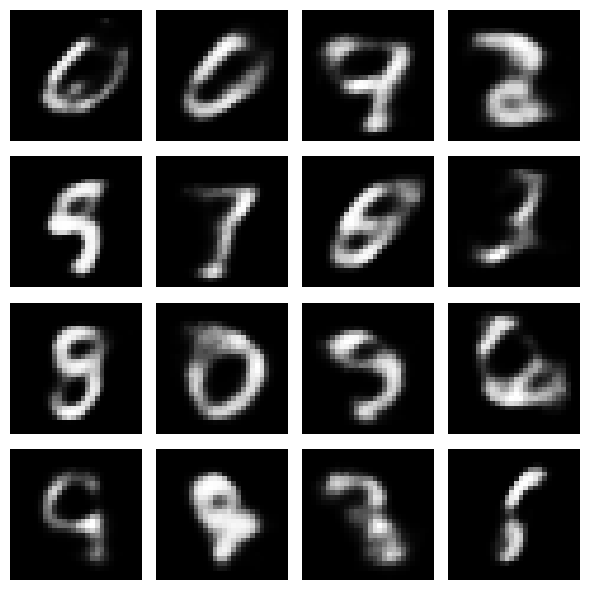

In [30]:
# TODO: Generate 16 new digits by sampling z ~ N(0,1) and passing through vae.decoder.

vae.eval()

with torch.no_grad():
    z = torch.randn(16, 16).to(device)
    generated = vae.decoder(z).cpu()

fig, axes = plt.subplots(4, 4, figsize=(6, 6))

for i, ax in enumerate(axes.flat):
    ax.imshow(generated[i].squeeze(), cmap="gray")
    ax.axis("off")

plt.tight_layout()
plt.show()


### ❓ Reflect — VAE
Answer in a markdown cell below:
1. Are the generated digits sharp or blurry? Why does this happen architecturally?
2. What does the KL divergence term in the loss do? What happens if you remove it?

# Your reflection here (convert to markdown cell)
(1) Generated images are relatively blurry, but this makes sense as VAEs architecturally are lighter and focus on reconstruction over image sharpness. The VAE's objective is to reconstruct from latent spaces, and because latent representations won't preserve every detail, the decoder may have several plausible reconstructions. It will minimize the reconstruction loss, producing intermediate pixel values and softer edges.

(2) The KL term regularizes the encoder's learned latent distribution closer to N(0,1), making the latent space continuous and organized. The "organized" part is clearer when seeing the outputs: removing the term causes the reconstruction loss to drop more quickly because the encoder is free to place each image wherever it wants in latent space, however, the resulting latent distribution no longer *has* to match N(0,1). Thus, randomly sampling from N(0,1) can land in regions the decoder never learned, producing incoherent or meaningless generated digits.

## Part 2 — GAN on MNIST
**Goal:** Train a GAN. Deliberately trigger mode collapse and document it.

In [18]:
class Generator(nn.Module):
    def __init__(self, z_dim=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(z_dim, 128), nn.ReLU(),
            nn.Linear(128, 256),   nn.ReLU(),
            nn.Linear(256, 784),   nn.Tanh(),
            nn.Unflatten(1, (1,28,28))
        )
    def forward(self, z): return self.net(z)

class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(784, 256), nn.LeakyReLU(0.2),
            nn.Linear(256, 128), nn.LeakyReLU(0.2),
            nn.Linear(128, 1),   nn.Sigmoid()
        )
    def forward(self, x): return self.net(x)

Epoch 1/10 | D Loss: 0.3405 | G Loss: 2.3962
Epoch 2/10 | D Loss: 0.0630 | G Loss: 4.9868
Epoch 3/10 | D Loss: 0.2183 | G Loss: 4.5095
Epoch 4/10 | D Loss: 0.3510 | G Loss: 3.6017
Epoch 5/10 | D Loss: 0.4707 | G Loss: 3.3070
Epoch 6/10 | D Loss: 0.5674 | G Loss: 2.9178
Epoch 7/10 | D Loss: 0.6910 | G Loss: 2.6139
Epoch 8/10 | D Loss: 0.6749 | G Loss: 2.6122
Epoch 9/10 | D Loss: 0.3733 | G Loss: 2.5072
Epoch 10/10 | D Loss: 0.2963 | G Loss: 3.3374


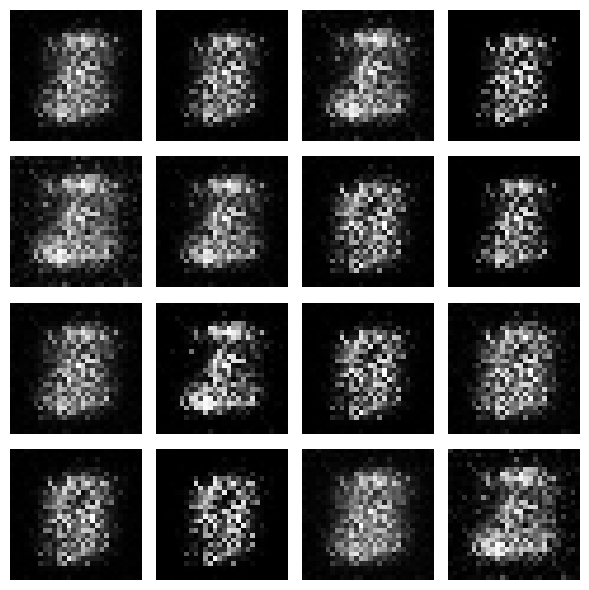

In [31]:
# TODO: Train the GAN for 10 epochs with BALANCED learning rates (lr=2e-4 for both G and D).

z_dim = 64
criterion = nn.BCELoss()

def train_gan(g_lr, d_lr, epochs=10):
    G = Generator(z_dim=z_dim).to(device)
    D = Discriminator().to(device)

    opt_G = torch.optim.Adam(G.parameters(), lr=g_lr)
    opt_D = torch.optim.Adam(D.parameters(), lr=d_lr)

    for epoch in range(epochs):
        total_g_loss = 0
        total_d_loss = 0

        for real, _ in loader:
            real = real.to(device)
            batch_size = real.size(0)

            # Generator outputs [-1, 1] because it uses Tanh.
            # MNIST is originally [0, 1], so rescale real images.
            real = real * 2 - 1

            real_labels = torch.ones(batch_size, 1, device=device)
            fake_labels = torch.zeros(batch_size, 1, device=device)

            opt_D.zero_grad()

            real_output = D(real)
            d_real_loss = criterion(real_output, real_labels)

            z = torch.randn(batch_size, z_dim, device=device)
            fake = G(z)

            fake_output = D(fake.detach())
            d_fake_loss = criterion(fake_output, fake_labels)

            d_loss = d_real_loss + d_fake_loss
            d_loss.backward()
            opt_D.step()

            opt_G.zero_grad()

            z = torch.randn(batch_size, z_dim, device=device)
            fake = G(z)

            output = D(fake)

            # Generator wants discriminator to call fake images "real"
            g_loss = criterion(output, real_labels)

            g_loss.backward()
            opt_G.step()

            total_d_loss += d_loss.item()
            total_g_loss += g_loss.item()

        print(
            f"Epoch {epoch + 1}/{epochs} | "
            f"D Loss: {total_d_loss / len(loader):.4f} | "
            f"G Loss: {total_g_loss / len(loader):.4f}"
        )

    return G, D


# Balanced GAN
G_good, D_good = train_gan(
    g_lr=2e-4,
    d_lr=2e-4,
    epochs=10
)

# Generate 16 examples
G_good.eval()

with torch.no_grad():
    z = torch.randn(16, z_dim, device=device)
    good_images = G_good(z).cpu()

# Convert [-1, 1] back to [0, 1] for display
good_images = (good_images + 1) / 2

fig, axes = plt.subplots(4, 4, figsize=(6, 6))

for i, ax in enumerate(axes.flat):
    ax.imshow(good_images[i].squeeze(), cmap="gray")
    ax.axis("off")

plt.tight_layout()
plt.show()

Epoch 1/10 | D Loss: 0.3464 | G Loss: 4.7621
Epoch 2/10 | D Loss: 0.4818 | G Loss: 7.5207
Epoch 3/10 | D Loss: 0.7823 | G Loss: 11.9506
Epoch 4/10 | D Loss: 0.4647 | G Loss: 5.5939
Epoch 5/10 | D Loss: 0.0354 | G Loss: 6.1787
Epoch 6/10 | D Loss: 0.0651 | G Loss: 62.7067
Epoch 7/10 | D Loss: 0.0000 | G Loss: 79.7888
Epoch 8/10 | D Loss: 0.0000 | G Loss: 79.6679
Epoch 9/10 | D Loss: 0.0000 | G Loss: 78.9719
Epoch 10/10 | D Loss: 0.0000 | G Loss: 77.5214


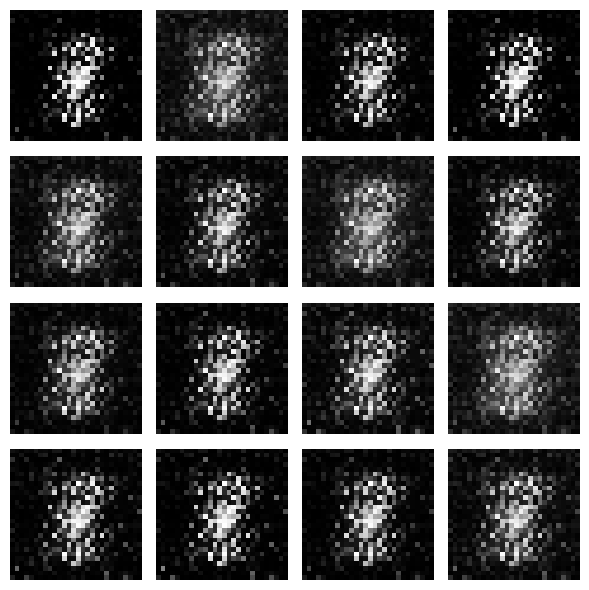

In [32]:
# TODO: Now TRIGGER MODE COLLAPSE: retrain with D learning rate 10x higher than G (e.g. D=2e-3, G=2e-4).

G_collapsed, D_collapsed = train_gan(
    g_lr=2e-4,
    d_lr=2e-3,
    epochs=10
)

# Generate 16 examples
G_collapsed.eval()

with torch.no_grad():
    z = torch.randn(16, z_dim, device=device)
    collapsed_images = G_collapsed(z).cpu()

# Convert [-1, 1] back to [0, 1]
collapsed_images = (collapsed_images + 1) / 2

fig, axes = plt.subplots(4, 4, figsize=(6, 6))

for i, ax in enumerate(axes.flat):
    ax.imshow(collapsed_images[i].squeeze(), cmap="gray")
    ax.axis("off")

plt.tight_layout()
plt.show()


### ❓ Reflect — GAN
1. Describe the mode collapse you triggered. What exactly happened visually?
2. Why does discriminator learning rate imbalance cause mode collapse? Explain the gradient flow.

(1) Here the mode collapse allowed the generator tricks the discriminator as seen by the panel of numbers that all look nearly identical but in different quality/variants, even though differrent random latent vectors were supplied. Because D's learning rate is sig higher, D adapts much faster than G, creating an unstable learning signal for G. G can then converge on a small subset of outputs that currently receive favorable gradients rather than continuing to learn diverse modes.

(2) Since D's learning rate is higher, it can converge more quickly than G and have larger learning steps. G receives its learning signal entirely through gradients propagated backward through D, so this imbalance creates an instability where G can "latch" onto a small subset of outputs to fool D. Because the standard GAN "game" rewards competition (fooling the discriminator) but does not explicitly reward output diversity, the generator can collapse onto this small subset family instead of learning the entire data distribution.

## Part 3 — FID Score Comparison
**Goal:** Compute FID for VAE and GAN outputs and interpret the result.

In [23]:
!pip install pytorch-fid --quiet

In [33]:
# TODO: Generate 1000 images from your VAE and 1000 from your GAN (post-collapse and pre-collapse versions).
import os
import shutil
from torchvision.utils import save_image

folders = [
    "./real_images",
    "./vae_images",
    "./gan_good",
    "./gan_collapsed"
]

for folder in folders:
    if os.path.exists(folder):
        shutil.rmtree(folder)
    os.makedirs(folder)

# Save 1000 real MNIST images

for i in range(1000):
    img, _ = train_data[i]
    save_image(img, f"./real_images/{i:04d}.png")

# Save 1000 VAE images

vae.eval()

num_images = 1000
batch_size = 100
saved = 0

with torch.no_grad():
    while saved < num_images:
        current_batch = min(batch_size, num_images - saved)

        z = torch.randn(current_batch, 16, device=device)
        images = vae.decoder(z).cpu()

        for j in range(current_batch):
            save_image(
                images[j],
                f"./vae_images/{saved + j:04d}.png"
            )

        saved += current_batch



# Save 1000 balanced GAN images
G_good.eval()
saved = 0

with torch.no_grad():
    while saved < num_images:
        current_batch = min(batch_size, num_images - saved)

        z = torch.randn(current_batch, z_dim, device=device)
        images = G_good(z).cpu()

        # Tanh output: [-1, 1] -> [0, 1]
        images = (images + 1) / 2

        for j in range(current_batch):
            save_image(
                images[j],
                f"./gan_good/{saved + j:04d}.png"
            )

        saved += current_batch


# --------------------------------------------------
# Save 1000 collapsed GAN images
# --------------------------------------------------

G_collapsed.eval()
saved = 0

with torch.no_grad():
    while saved < num_images:
        current_batch = min(batch_size, num_images - saved)

        z = torch.randn(current_batch, z_dim, device=device)
        images = G_collapsed(z).cpu()

        images = (images + 1) / 2

        for j in range(current_batch):
            save_image(
                images[j],
                f"./gan_collapsed/{saved + j:04d}.png"
            )

        saved += current_batch


print("Saved 1000 images to each folder.")


Saved 1000 images to each folder.


In [34]:
!python -m pytorch_fid ./real_images/ ./vae_images/
!python -m pytorch_fid ./real_images/ ./gan_good/
!python -m pytorch_fid ./real_images/ ./gan_collapsed/

100% 20/20 [00:04<00:00,  4.38it/s]
100% 20/20 [00:04<00:00,  4.51it/s]
FID:  78.80644667403419
100% 20/20 [00:04<00:00,  4.47it/s]
100% 20/20 [00:04<00:00,  4.77it/s]
FID:  258.197519108803
100% 20/20 [00:04<00:00,  4.45it/s]
100% 20/20 [00:04<00:00,  4.52it/s]
/usr/local/lib/python3.13/dist-packages/pytorch_fid/fid_score.py:188: LinAlgWarning: Matrix is singular. The result might be inaccurate or the array might not have a square root.
  covmean, _ = linalg.sqrtm(sigma1.dot(sigma2), disp=False)
FID:  287.3840119820941


### FID Results

- VAE FID: 78.81
- Balanced GAN FID: 258.20
- Collapsed GAN FID: 287.38

Here, the VAE wins in terms of FID, giving us the best mix between diversity (covering the real data distribution) and realism (meaningful images)

### ❓ Final Reflection — Production Decision
Your client needs **synthetic medical imaging data**. They have 300 labelled scans.

1. Which model (VAE or GAN) do you recommend and why?
2. What breaks first at 300 training examples?
3. What metric would you use to validate the synthetic data before using it for classifier training?

(1) I would start with a VAE, as we are dealing with a relatively low dataset count and the goal here is to expand the dataset. GANs are great when we need sharper images, but the smaller dataset here could cause overfitting of D and lead to mode collapse. VAEs are much more stable in training, especially with smaller datasets. We would just need to QA generated outputs thoroughly for fine/medically-relevant data being preserved during reconstruction, as VAE images can be blurry.

(2) At 300 training examples, the main concern would be overfitting and memorization of the dataset. This is especially why a GAN isn't well-suited here, as D could easily out-compete G in the adversarial game and memorize the dataset.

(3) FID is suited here as an initial metric to see how the synthetic distribution's similarity to the real image distribution: lower FID would be better here as telling us we have statistical similarity. I would not only stick with this metric though, as I would want to make sure that true medical details are being preserved in the synthetic images to gauge medical validity as VAE images will oftentimes be blurry

---
## Submission
- [ ] Push to `genai-course/week1/lab1.ipynb`
- [ ] All TODO cells completed and run
- [ ] Reflection questions answered
- [ ] Best generated image grid in README